In [ ]:
import os
from os.path import join as pj
import argparse
import sys
sys.path.append("modules")
import utils
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.mixture import GaussianMixture
import seaborn as sns
from joblib import Parallel, delayed
import rpy2.robjects as robjects
import umap
import re
import matplotlib.pyplot as plt
from sklearn import metrics
import scanpy as sc
import pandas as pd
import csv

2025-01-23 09:37:10.171862: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


In [ ]:
parser = argparse.ArgumentParser()
parser.add_argument('--task', type=str, default='atlas_disease_cl')
parser.add_argument('--reference', type=str, default='atlas_new')
parser.add_argument('--experiment', type=str, default='c_2')
parser.add_argument('--model', type=str, default='default')
parser.add_argument('--init_model', type=str, default='')
parser.add_argument('--init_model_ref', type=str, default='sp_latest')
parser.add_argument('--method', type=str, default='midas_embed')
o, _ = parser.parse_known_args()  # for python interactive
# o = parser.parse_args()

# Load data and labels

In [3]:
# load latent variables
data_config = utils.gen_data_config(o.task)
data_config_ref = utils.gen_data_config(o.reference)
data_config_ref["raw_data_dirs"] += data_config["raw_data_dirs"][:17]
data_config_ref["raw_data_frags"] += data_config["raw_data_frags"][:17]
data_config_ref["combs"] = data_config["combs"][:51]
data_config_ref["comb_ratios"] = data_config["comb_ratios"][:51]
data_config_ref["s_joint"] = data_config["s_joint"][:51]
for k, v in data_config_ref.items():
    vars(o)[k] = v
model_config = utils.load_toml("configs/model.toml")["default"]
if o.model != "default":
    model_config.update(utils.load_toml("configs/model.toml")[o.model])
for k, v in model_config.items():
    vars(o)[k] = v
o.s_joint, o.combs, *_ = utils.gen_all_batch_ids(o.s_joint, o.combs)

o.pred_dir = pj("result", o.task, o.experiment, o.model, "predict", o.init_model)
pred = utils.load_predicted(o, group_by="subset")

c = [v["z"]["joint"][:, :o.dim_c] for v in pred.values()]
subset_num = 44
c_ref = np.concatenate(c[:subset_num], axis=0)
c_query = np.concatenate(c[subset_num:], axis=0)
c_all = np.concatenate([c_query, c_ref], axis=0)

  0%|          | 0/24 [00:00<?, ?it/s]

Loading predicted variables ...
Loading subset 0: z, joint
Loading subset 1: z, joint


 38%|███▊      | 15/40 [00:00<00:00, 148.64it/s]

Loading subset 2: z, joint


 39%|███▉      | 15/38 [00:00<00:00, 133.67it/s]

...

Loading subset 43: z, joint


 61%|██████    | 23/38 [00:00<00:00, 225.25it/s]

Loading subset 44: z, joint
Loading subset 45: z, joint
Loading subset 46: z, joint


100%|██████████| 2/2 [00:00<00:00, 140.82it/s]


Loading subset 47: z, joint
Loading subset 48: z, joint
Loading subset 49: z, joint
Loading subset 50: z, joint
Converting to numpy ...
Converting subset 0: s, joint
Converting subset 0: z, joint
Converting subset 1: s, joint
Converting subset 1: z, joint
Converting subset 2: s, joint
Converting subset 2: z, joint
Converting subset 3: s, joint
Converting subset 3: z, joint
Converting subset 4: s, joint
Converting subset 4: z, joint
Converting subset 5: s, joint
Converting subset 5: z, joint
Converting subset 6: s, joint
Converting subset 6: z, joint
Converting subset 7: s, joint
Converting subset 7: z, joint
Converting subset 8: s, joint
Converting subset 8: z, joint
Converting subset 9: s, joint
Converting subset 9: z, joint
Converting subset 10: s, joint
Converting subset 10: z, joint
Converting subset 11: s, joint
Converting subset 11: z, joint
Converting subset 12: s, joint
Converting subset 12: z, joint
Converting subset 13: s, joint
Converting subset 13: z, joint
Converting subse

In [ ]:
label_ref = np.array(robjects.r['as.matrix'](robjects.r['readRDS']("./result/comparison/atlas_disease_cl/midas_embed/c_1/default/celltype_1.4.rds")), dtype=object)
label_query = np.array(["query"]*c_query.shape[0])
label_train = np.concatenate([label_query, label_ref])

In [ ]:
pd.DataFrame(label_ref).to_csv("./analysis/atlas_label/atlas_disease_1.csv")

In [29]:
labels = []
for raw_data_dir in o.raw_data_dirs[44:]:
    label = utils.load_csv(pj(raw_data_dir, "label_seurat", "l1.csv"))
    labels += utils.transpose_list(label)[1][1:]
labels = np.array(labels)
label_gt_l1 = labels

# Transfer labels with kNNs

In [30]:
knn = KNeighborsClassifier(n_neighbors=100, weights='uniform')
knn.fit(c_all, label_train)

KNeighborsClassifier(n_neighbors=100)

/root/anaconda3/lib/python3.8/site-packages/sklearn/neighbors/_classification.py:237: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


<AxesSubplot:ylabel='Count'>

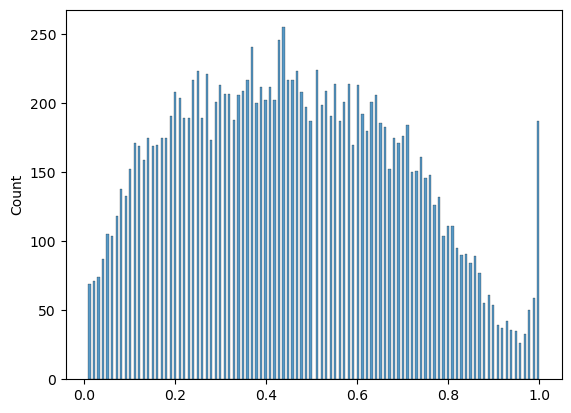

In [31]:
def predict_batch(X, knn_model):
    return knn_model.predict(X)

def predict_prob_batch(X, knn_model):
    return knn_model.predict_proba(X)

def knn_predict_par(X, knn_model, num_cores):
    X_batches = np.array_split(X, num_cores)
    with Parallel(n_jobs=num_cores, backend="threading") as parallel:
        results = parallel(delayed(predict_batch)(X_batch, knn_model) for X_batch in X_batches)
    return np.concatenate(results)

def knn_predict_prob_par(X, knn_model, num_cores):
    X_batches = np.array_split(X, num_cores)
    with Parallel(n_jobs=num_cores, backend="threading") as parallel:
        results = parallel(delayed(predict_prob_batch)(X_batch, knn_model) for X_batch in X_batches)
    return np.concatenate(results)

prob_pred = knn_predict_prob_par(c_query, knn, 36)
pred_label = knn_predict_par(c_query, knn, 36)
prob_pred_unknown = prob_pred[:, -1]
sns.histplot(data=prob_pred_unknown, bins=200)

In [ ]:
result_dir = pj("result", "comparison", o.task, o.method, o.experiment, o.model, o.init_model)
utils.mkdirs(result_dir, remove_old=False)
label_pred = knn.classes_[np.argmax(prob_pred[:, :-1], axis = 1)]
label_pred[prob_pred_unknown > 0.98] = "Unknown" # confusion

utils.save_list_to_csv([list(line) for line in list(label_pred.reshape(-1, 1))], pj(result_dir, "label_transferred_nonumap_new.csv"))
# utils.save_list_to_csv([list(line) for line in list(label_gt_l1.reshape(-1, 1))], pj(result_dir, "label_gt_nonumap_new.csv"))
utils.save_list_to_csv([list(line) for line in list(label_gt_l1.reshape(-1, 1))], pj(result_dir, "label_gt_seurat_new.csv"))